In [22]:
# ===============================
# CELL 1: IMPORTS & GLOBAL CONFIG
# ===============================

# Standard libs
import os
import sys
import json
import warnings
from typing import Dict, List

# Data libs
import numpy as np
import pandas as pd

# Viz libs
import matplotlib.pyplot as plt
import seaborn as sns

# ML libs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Explainability
import shap

# Persistence
import joblib

# RAG
from sentence_transformers import SentenceTransformer
import chromadb

# API
from alpha_vantage.timeseries import TimeSeries

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = r"C:\Users\valen\PycharmProjects\NEW_SalaryAIPredicator\Salary_Data.csv"
PAYSLIP_PATH = r"C:\Users\valen\PycharmProjects\NEW_SalaryAIPredicator\payslips"
ALPHA_VANTAGE_KEY = "BU3EDDWZ30K6YMPF"

sns.set(style="whitegrid")


In [23]:
# ===============================
# CELL 2: CUSTOM EXCEPTIONS
# ===============================

class SalarySystemError(Exception):
    """Base exception for Salary AI system"""
    pass


In [24]:
# ===============================
# CELL 3: DATA LOADER (OOP)
# ===============================

class SalaryDataLoader:
    def __init__(self, path: str):
        self.path = path
        self.df = None

    def load(self) -> pd.DataFrame:
        try:
            if not os.path.exists(self.path):
                raise SalarySystemError("Dataset path no dey exist")

            self.df = pd.read_csv(self.path)
            return self.df

        except Exception as e:
            raise SalarySystemError(f"Data loading failed: {e}")


In [25]:
# ===============================
# CELL 4: DATA CLEANER
# ===============================

class SalaryDataCleaner:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    def normalize_education(self):
        edu_map = {
            "Masters": "Master's",
            "Master": "Master's",
            "HighSchool": "High School",
            "Highschool": "High School"
        }
        self.df["Education Level"] = self.df["Education Level"].replace(edu_map)
        return self

    def strip_strings(self):
        for col in self.df.select_dtypes(include="object").columns:
            self.df[col] = self.df[col].str.strip()
        return self

    def handle_missing(self):
        self.df = self.df.dropna(subset=["Salary"])
        return self

    def clean(self) -> pd.DataFrame:
        return (
            self.strip_strings()
            .normalize_education()
            .handle_missing()
            .df
        )


In [26]:
# ===============================
# CELL 5: LOAD & CLEAN DATA
# ===============================

loader = SalaryDataLoader(DATA_PATH)
raw_df = loader.load()

cleaner = SalaryDataCleaner(raw_df)
df = cleaner.clean()

df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [27]:
# ===============================
# CELL 6: BASIC EDA
# ===============================

print(df.info())
print(df.describe().T)
print(df["Education Level"].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 6699 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6699 non-null   float64
 1   Gender               6699 non-null   object 
 2   Education Level      6698 non-null   object 
 3   Job Title            6699 non-null   object 
 4   Years of Experience  6699 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 366.4+ KB
None
                      count           mean           std    min      25%  \
Age                  6699.0      33.622033      7.615646   21.0     28.0   
Years of Experience  6699.0       8.095014      6.059853    0.0      3.0   
Salary               6699.0  115326.964771  52786.183911  350.0  70000.0   

                          50%       75%       max  
Age                      32.0      38.0      62.0  
Years of Experience       7.0  

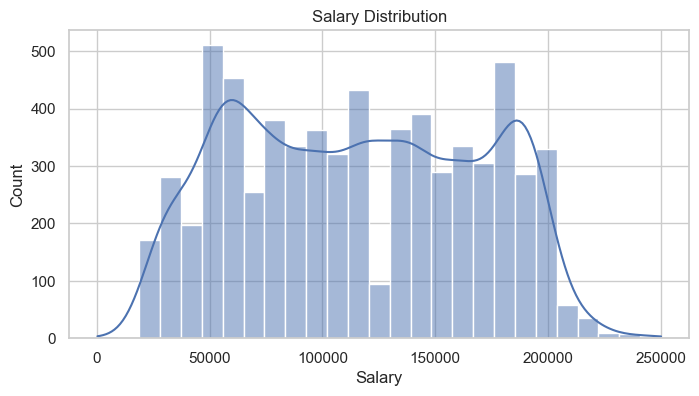

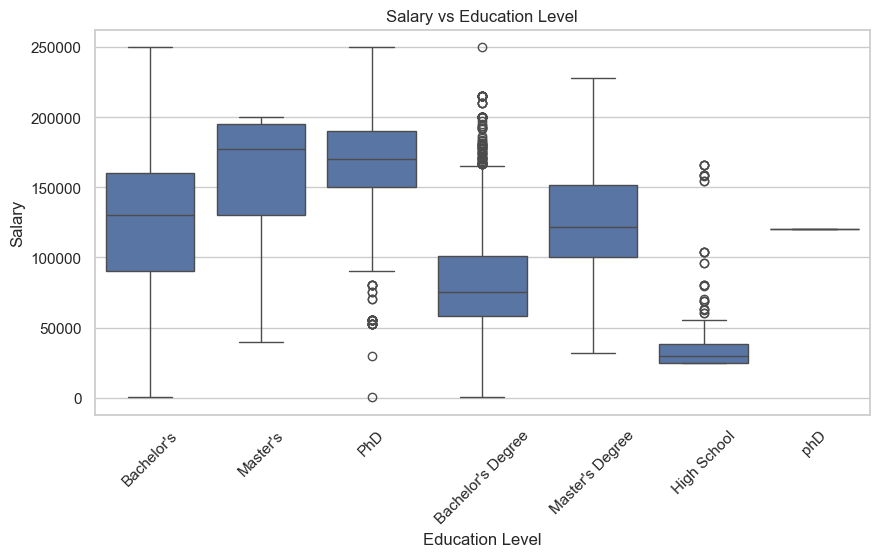

In [28]:
# ===============================
# CELL 7: SALARY DISTRIBUTION
# ===============================

plt.figure(figsize=(8,4))
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Education Level", y="Salary", data=df)
plt.xticks(rotation=45)
plt.title("Salary vs Education Level")
plt.show()


In [29]:
# ===============================
# CELL 8: FEATURES & TARGET
# ===============================

TARGET = "Salary"

X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()


In [30]:
# ===============================
# CELL 9: PREPROCESSOR
# ===============================

class PreprocessorFactory:
    @staticmethod
    def build(num_cols, cat_cols):
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        return ColumnTransformer([
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ])


In [31]:
# ===============================
# CELL 10: MODEL FACTORY
# ===============================

class ModelFactory:
    @staticmethod
    def get_models():
        return {
            "Linear": LinearRegression(),
            "Ridge": Ridge(),
            "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
            "GradientBoost": GradientBoostingRegressor(random_state=RANDOM_STATE),
            "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE),
            "SVR": SVR()
        }


In [32]:
# ===============================
# CELL 11: TRAIN & COMPARE MODELS
# ===============================

class ModelTrainer:
    def __init__(self, preprocessor, models):
        self.preprocessor = preprocessor
        self.models = models
        self.results = {}

    def train_all(self, X_train, X_test, y_train, y_test):
        for name, model in self.models.items():
            pipe = Pipeline([
                ("prep", self.preprocessor),
                ("model", model)
            ])
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)

            self.results[name] = {
                "RMSE": rmse,
                "R2": r2,
                "model": pipe
            }
        return self.results


In [33]:
# ===============================
# CELL 12: EXECUTION
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = PreprocessorFactory.build(num_cols, cat_cols)
models = ModelFactory.get_models()

trainer = ModelTrainer(preprocessor, models)
results = trainer.train_all(X_train, X_test, y_train, y_test)

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df


,RMSE,R2,model
RandomForest,6550.713989,0.984906,"(ColumnTransformer(transformers=[('num',\n ..."
XGBoost,7426.566762,0.9806,"(ColumnTransformer(transformers=[('num',\n ..."
GradientBoost,14395.226665,0.92711,"(ColumnTransformer(transformers=[('num',\n ..."
Linear,18598.732576,0.878326,"(ColumnTransformer(transformers=[('num',\n ..."
Ridge,18607.762508,0.878208,"(ColumnTransformer(transformers=[('num',\n ..."
SVR,52958.388072,0.013496,"(ColumnTransformer(transformers=[('num',\n ..."


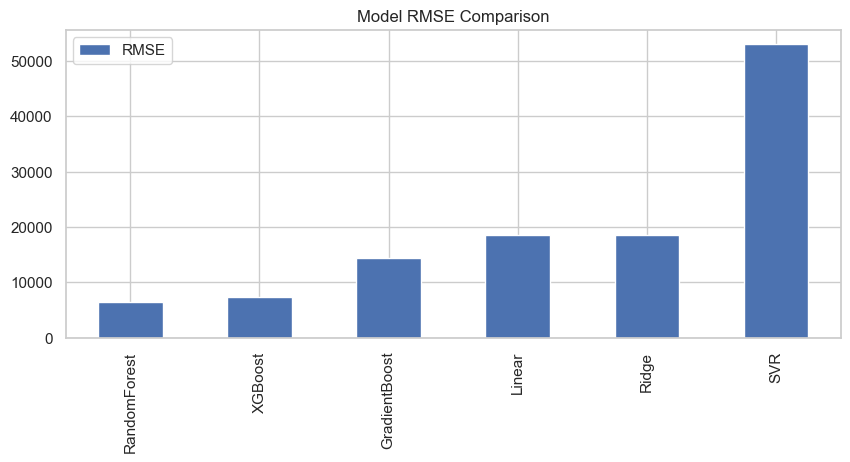

In [34]:
# ===============================
# CELL 13: MODEL COMPARISON VISUAL
# ===============================

results_df[["RMSE"]].plot(kind="bar", figsize=(10,4))
plt.title("Model RMSE Comparison")
plt.show()


In [35]:
# ===============================
# CELL 14: BIAS CHECKER
# ===============================

class BiasChecker:
    def __init__(self, model, X, y):
        self.model = model
        self.X = X
        self.y = y

    def check_by_group(self, column):
        df_bias = self.X.copy()
        df_bias["Actual"] = self.y
        df_bias["Predicted"] = self.model.predict(self.X)

        return df_bias.groupby(column)[["Actual","Predicted"]].mean()


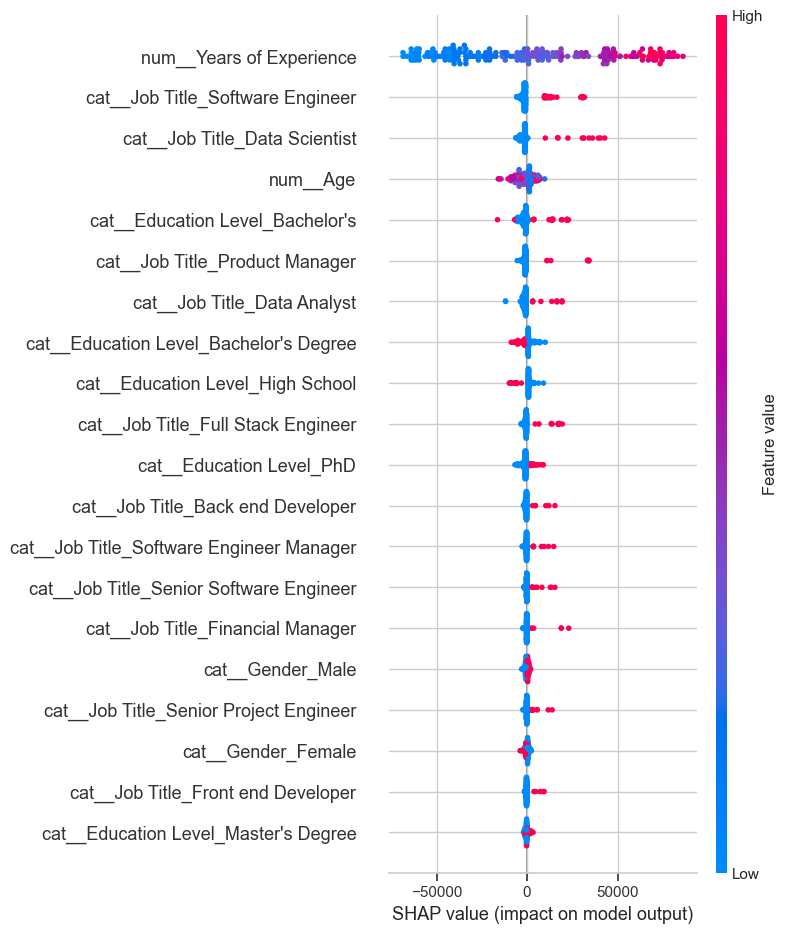

In [38]:
# ===============================
# CELL 15: SHAP EXPLAINABILITY (FAST & SAFE)
# ===============================

import shap
import numpy as np

best_model = results_df.iloc[0]["model"]

prep = best_model.named_steps["prep"]
model = best_model.named_steps["model"]

# Transform data
X_transformed = prep.transform(X_train)

# Convert sparse to dense
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

X_transformed = X_transformed.astype(np.float64)

# Get feature names
feature_names = prep.get_feature_names_out()

#  SAMPLE DATA (CRITICAL FOR SPEED)
sample_size = min(200, X_transformed.shape[0])
idx = np.random.choice(X_transformed.shape[0], sample_size, replace=False)
X_sample = X_transformed[idx]

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values (FAST)
shap_values = explainer.shap_values(X_sample)

# Plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)


In [39]:
# ===============================
# CELL 16: RAG ENGINE
# ===============================

class PayslipRAG:
    def __init__(self, folder):
        self.model = SentenceTransformer("all-MiniLM-L6-v2")
        self.client = chromadb.Client()
        self.collection = self.client.create_collection("payslips")

        self._load(folder)

    def _load(self, folder):
        for file in os.listdir(folder):
            with open(os.path.join(folder, file), "r", errors="ignore") as f:
                text = f.read()
                emb = self.model.encode(text).tolist()
                self.collection.add(
                    documents=[text],
                    embeddings=[emb],
                    ids=[file]
                )

    def query(self, text):
        emb = self.model.encode(text).tolist()
        return self.collection.query(embeddings=[emb], n_results=3)


In [40]:
# ===============================
# CELL 17: MARKET DATA API
# ===============================

class MarketSignal:
    def __init__(self, api_key):
        self.ts = TimeSeries(key=api_key, output_format="pandas")

    def get_tech_index(self):
        data, _ = self.ts.get_daily(symbol="NASDAQ", outputsize="compact")
        return data.tail(1)


In [41]:
# ===============================
# CELL 18: SAVE BEST MODEL
# ===============================

joblib.dump(best_model, "best_salary_model.pkl")
print("Model saved successfully")


Model saved successfully
